In [62]:
import numpy as np
import pandas as pd
food_consumption = pd.read_csv('food_consumption.csv')
food_consumption.head()


,Unnamed: 0,country,food_category,consumption,co2_emission
0,1,Argentina,pork,10.51,37.20
1,2,Argentina,poultry,38.66,41.53
2,3,Argentina,beef,55.48,1712.00
3,4,Argentina,lamb_goat,1.56,54.63
4,5,Argentina,fish,4.36,6.96


In [63]:
be_consumption = food_consumption[food_consumption['country'] == 'Belgium']
usa_consumption = food_consumption[food_consumption['country'] == 'USA']
print(be_consumption.head())
print(usa_consumption.head())

     Unnamed: 0  country food_category  consumption  co2_emission
396         397  Belgium          pork        38.65        136.80
397         398  Belgium       poultry        12.20         13.11
398         399  Belgium          beef        15.63        482.31
399         400  Belgium     lamb_goat         1.32         46.23
400         401  Belgium          fish        18.97         30.29
    Unnamed: 0 country food_category  consumption  co2_emission
55          56     USA          pork        27.64         97.83
56          57     USA       poultry        50.01         53.72
57          58     USA          beef        36.24       1118.29
58          59     USA     lamb_goat         0.43         15.06
59          60     USA          fish        12.35         19.72


In [64]:
np.mean(be_consumption['consumption'])
np.median(be_consumption['consumption'].sort_values())
np.mean(usa_consumption['consumption'])
np.median(usa_consumption['consumption'].sort_values())

np.float64(14.58)

In [65]:
be_and_usa = food_consumption[food_consumption['country'].isin(['Belgium', 'USA'])]
be_and_usa.head()

,Unnamed: 0,country,food_category,consumption,co2_emission
55,56,USA,pork,27.64,97.83
56,57,USA,poultry,50.01,53.72
57,58,USA,beef,36.24,1118.29
58,59,USA,lamb_goat,0.43,15.06
59,60,USA,fish,12.35,19.72


In [66]:
group_by_country = be_and_usa.groupby('country')['consumption']
group_by_country.head()

55     27.64
56     50.01
57     36.24
58      0.43
59     12.35
396    38.65
397    12.20
398    15.63
399     1.32
400    18.97
Name: consumption, dtype: float64

In [67]:
mean_median = group_by_country.agg(['mean', 'median'])
print(mean_median)

              mean  median
country                   
Belgium  42.132727   12.59
USA      44.650000   14.58


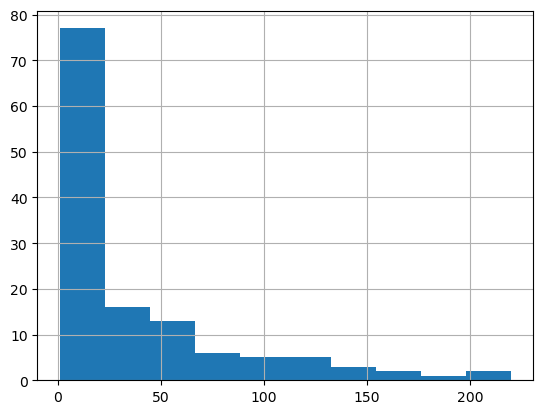

In [68]:
import matplotlib.pyplot as plt
rice_consumption = food_consumption[food_consumption['food_category'] == 'rice']
rice_consumption['co2_emission'].hist()
plt.show()

In [69]:
print(rice_consumption['co2_emission'].agg(['mean','median']))

mean      37.591615
median    15.200000
Name: co2_emission, dtype: float64


In [70]:
# Calculate the quartiles of co2_emission
print(np.quantile(food_consumption['co2_emission'],[0,0.25,0.5,0.75,1]))

# Calculate the quantiles of co2_emission
print(np.quantile(food_consumption['co2_emission'],[0,0.2,0.4,0.6,0.8,1]))

print(np.quantile(food_consumption['co2_emission'],[0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1]))

[   0.        5.21     16.53     62.5975 1712.    ]
[   0.       3.54    11.026   25.59    99.978 1712.   ]
[0.00000e+00 6.68000e-01 3.54000e+00 7.04000e+00 1.10260e+01 1.65300e+01
 2.55900e+01 4.42710e+01 9.99780e+01 2.03629e+02 1.71200e+03]


In [71]:
print(food_consumption.groupby('food_category')['co2_emission'].agg(['var','std']))

                        var         std
food_category                          
beef           88748.408132  297.906710
dairy          17671.891985  132.935669
eggs              21.371819    4.622966
fish             921.637349   30.358481
lamb_goat      16475.518363  128.356996
nuts              35.639652    5.969895
pork            3094.963537   55.632396
poultry          245.026801   15.653332
rice            2281.376243   47.763754
soybeans           0.879882    0.938020
wheat             71.023937    8.427570


<Axes: >

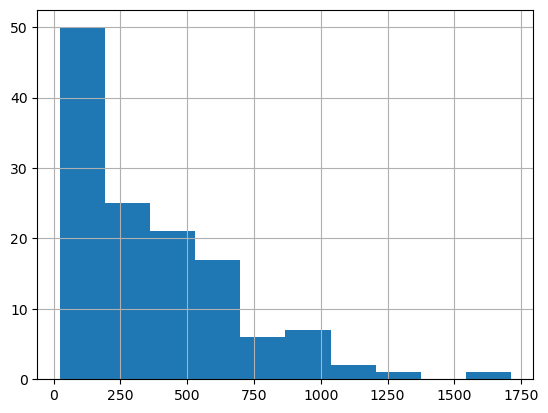

In [72]:
import matplotlib.pyplot as plt
food_consumption[food_consumption['food_category'] == 'beef']['co2_emission'].hist()

<Axes: >

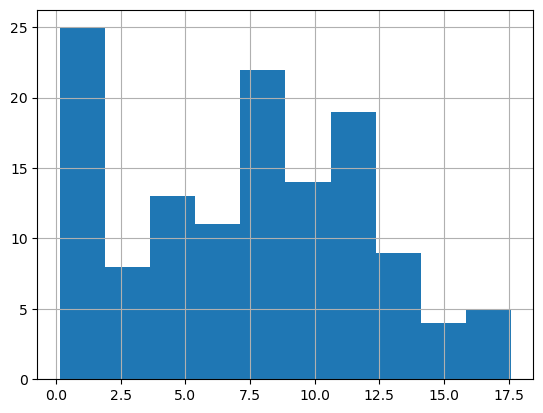

In [73]:
food_consumption[food_consumption['food_category'] == 'eggs']['co2_emission'].hist()

In [74]:
emissions_by_country = food_consumption.groupby('country')['co2_emission'].sum()

q1 = np.quantile(emissions_by_country, 0.25)
q3 = np.quantile(emissions_by_country, 0.75)
iqr = q3 - q1

lower = q1 - 1.5* iqr
upper = q3 + 1.5 * iqr

outliers = emissions_by_country[(emissions_by_country<lower) | (emissions_by_country > upper)]
non_outliers = emissions_by_country[(emissions_by_country>=lower)| (emissions_by_country<=upper)]
print(outliers)

country
Argentina    2172.4
Name: co2_emission, dtype: float64


In [75]:
amir_deals = pd.read_csv('amir_deals.csv')
counts = amir_deals['product'].value_counts()
probs = counts / amir_deals.shape[0]
print(probs)

product
Product B    0.348315
Product D    0.224719
Product A    0.129213
Product C    0.084270
Product F    0.061798
Product H    0.044944
Product I    0.039326
Product E    0.028090
Product N    0.016854
Product G    0.011236
Product J    0.011236
Name: count, dtype: float64


In [76]:
np.random.seed(24)

sample_without_replacement = amir_deals.sample(5)
print(sample_without_replacement)

sample_with_replacement = amir_deals.sample(5, replace=True)
print(sample_with_replacement)

     Unnamed: 0    product   client status   amount  num_users
127         128  Product B  Current    Won  2070.25          7
148         149  Product D  Current    Won  3485.48         52
77           78  Product B  Current    Won  6252.30         27
104         105  Product D  Current    Won  4110.98         39
166         167  Product C      New   Lost  3779.86         11
     Unnamed: 0    product   client status   amount  num_users
133         134  Product D  Current    Won  5992.86         98
101         102  Product H  Current    Won  5116.34         63
110         111  Product B  Current    Won   696.88         44
49           50  Product B  Current    Won  3488.36         79
56           57  Product D  Current    Won  6820.84         42


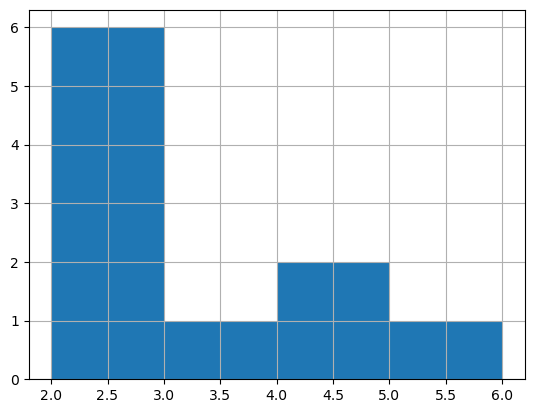

   group_size  prob
0           2   0.6
1           4   0.2
2           6   0.1
3           3   0.1
The expected value is 2.9000000000000004
The probability is 0.30000000000000004


In [77]:
restaurant_groups = pd.read_csv('restaurant_groups.csv')
restaurant_groups['group_size'].hist(bins=[2,3,4,5,6])
plt.show()
size_dist = restaurant_groups['group_size'].value_counts() / restaurant_groups.shape[0]
size_dist = size_dist.reset_index()
size_dist.columns = ['group_size', 'prob']
print(size_dist)
expected_value = np.sum(size_dist['group_size'] * size_dist['prob'])
print('The expected value is', expected_value)

groups_4_or_more = size_dist[size_dist['group_size'] >= 4]

prob_4_or_more = np.sum(groups_4_or_more['prob'])
print('The probability is', prob_4_or_more)

In [78]:
min_time = 0
max_time = 30

from scipy.stats import uniform

prob_less_than_5= uniform.cdf(5, 0, 30)
print(prob_less_than_5)

prob_greater_than_5 = 1-uniform.cdf(5, 0, 30)
print(prob_greater_than_5)

prob_between_10_and_20 = uniform.cdf(20,0,30)-uniform.cdf(10,0,30)
print(prob_between_10_and_20)

0.16666666666666666
0.8333333333333334
0.3333333333333333


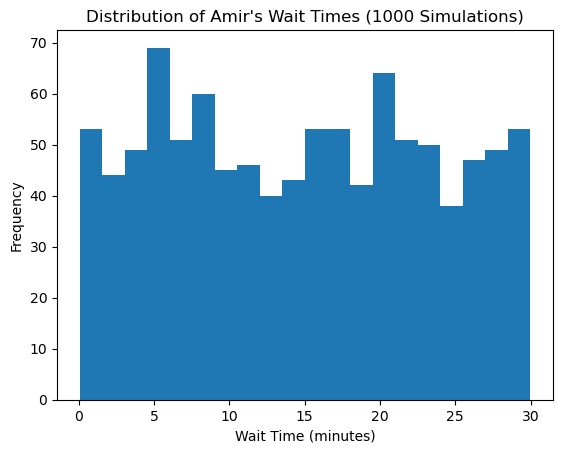

In [79]:
# Set the random seed to 334
np.random.seed(334)

# Generate 1000 wait times from the continuous uniform distribution (min=0, max=30)
wait_times = np.random.uniform(0, 30, 1000)

# Create a histogram of the simulated wait times and show the plot
plt.hist(wait_times, bins=20)
plt.xlabel('Wait Time (minutes)')
plt.ylabel('Frequency')
plt.title('Distribution of Amir\'s Wait Times (1000 Simulations)')
plt.show()

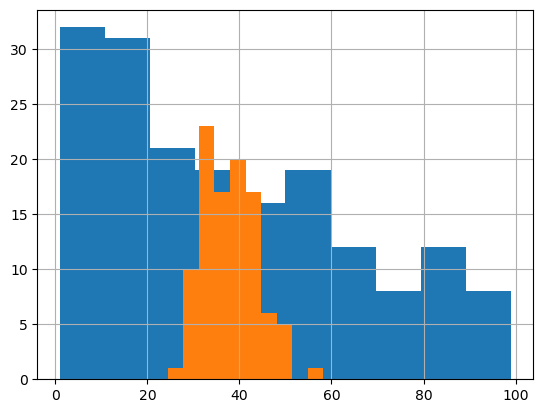

In [80]:
amir_deals['num_users'].hist()
np.random.seed(104)
sample_means = []
# Loop 100 times
for i in range(100):
    # Take sample of 20 num_users
    samp_20 = amir_deals['num_users'].sample(20, replace=True)
    # Calculate mean of samp_20
    samp_20_mean = np.mean(samp_20)
    # Append samp_20_mean to sample_means
    sample_means.append(samp_20_mean)
# Convert to Series and plot histogram
sample_means_series = pd.Series(sample_means)
sample_means_series.hist()
# Show plot
plt.show()


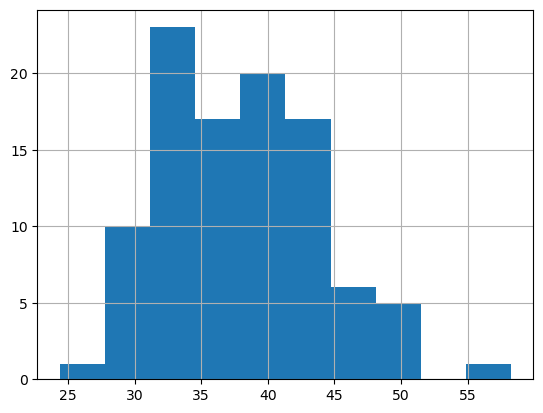

In [81]:
np.random.seed(104)
sample_means = []
# Loop 100 times
for i in range(100):
    # Take sample of 20 num_users
    samp_20 = amir_deals['num_users'].sample(20, replace=True)
    # Calculate mean of samp_20
    samp_20_mean = np.mean(samp_20)
    # Append samp_20_mean to sample_means
    sample_means.append(samp_20_mean)
# Convert to Series and plot histogram
sample_means_series = pd.Series(sample_means)
sample_means_series.hist()
# Show plot
plt.show()

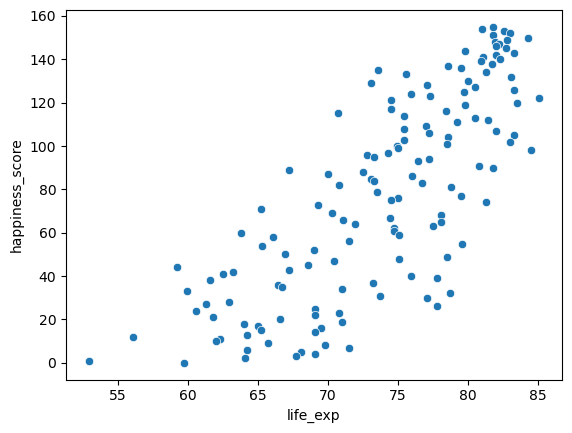

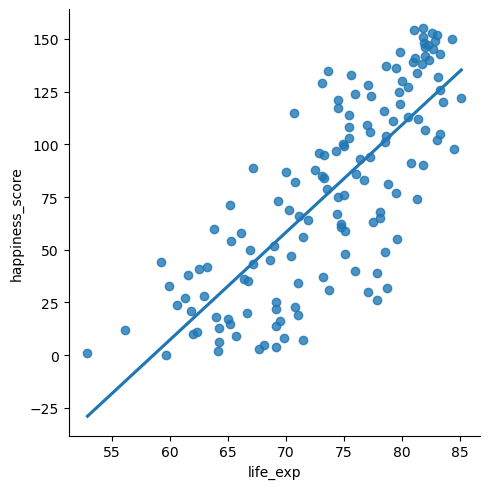

0.7802249053272062


In [82]:
import seaborn as sns
world_happiness = pd.read_csv('world_happiness.csv')
sns.scatterplot(x='life_exp',y='happiness_score', data=world_happiness)
plt.show()

sns.lmplot(x='life_exp', y='happiness_score', data=world_happiness, ci=None)
plt.show()

cor = world_happiness['life_exp'].corr(world_happiness['happiness_score'])
print(cor)

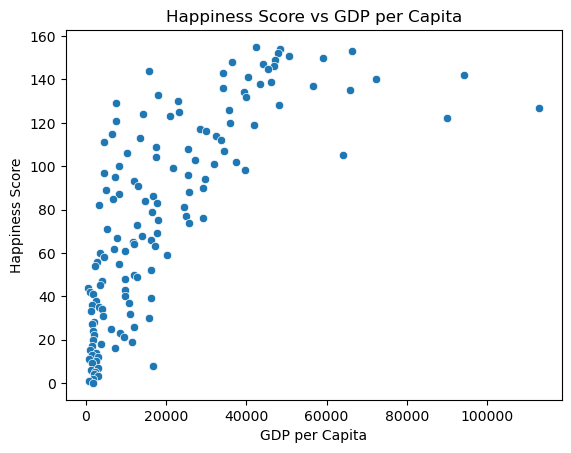

Correlation between GDP per capita and happiness score: 0.7280


In [83]:
# Scatterplot of happiness_score vs gdp_per_cap
import matplotlib.pyplot as plt
import seaborn as sns

# Create scatterplot and calculate correlation
sns.scatterplot(x='gdp_per_cap', y='happiness_score', data=world_happiness)
plt.xlabel('GDP per Capita')
plt.ylabel('Happiness Score')
plt.title('Happiness Score vs GDP per Capita')
plt.show()

cor_gdp = world_happiness['gdp_per_cap'].corr(world_happiness['happiness_score'])
print(f"Correlation between GDP per capita and happiness score: {cor_gdp:.4f}")

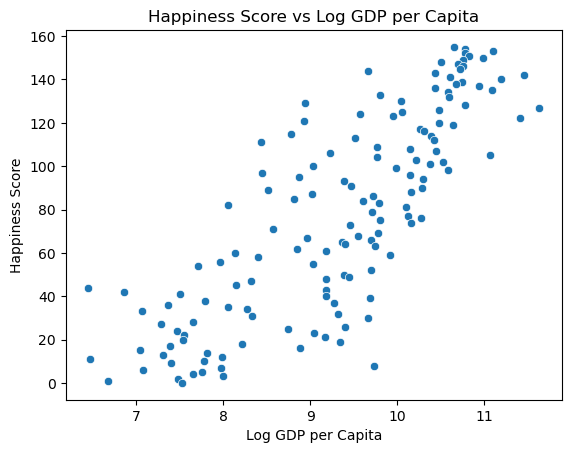

Correlation between log GDP per capita and happiness score: 0.8043

Comparison:
Original GDP correlation: 0.7280
Log GDP correlation:      0.8043
The log transformation improved the correlation by: 0.0763


In [84]:
# Add log-transformed GDP per capita column
world_happiness['log_gdp_per_cap'] = np.log(world_happiness['gdp_per_cap'])

# Create scatterplot of happiness_score vs log_gdp_per_cap
sns.scatterplot(x='log_gdp_per_cap', y='happiness_score', data=world_happiness)
plt.xlabel('Log GDP per Capita')
plt.ylabel('Happiness Score')
plt.title('Happiness Score vs Log GDP per Capita')
plt.show()

cor_log_gdp = world_happiness['log_gdp_per_cap'].corr(world_happiness['happiness_score'])
print(f"Correlation between log GDP per capita and happiness score: {cor_log_gdp:.4f}")

print(f"\nComparison:")
print(f"Original GDP correlation: {cor_gdp:.4f}")
print(f"Log GDP correlation:      {cor_log_gdp:.4f}")
print(f"The log transformation improved the correlation by: {cor_log_gdp - cor_gdp:.4f}")